In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN,Dense,LSTM

from sklearn.preprocessing import MinMaxScaler #Stock Prices to range(0 to 1) as NN wroks better with small values
from sklearn.metrics import mean_squared_error,r2_score #For Regression we use MAE,MSE,RMSE,r2 score
#Smaller RMSE ->BETTER PRED
#R2 Score->closer to 1 ->BETTER Model

In [183]:
df=pd.read_csv("goog.csv")
df.head()

,Date,Open,High,Low,Close,Volume
0,12/19/2016,790.219971,797.659973,786.270020,794.200012,1225900
1,12/20/2016,796.760010,798.650024,793.270020,796.419983,925100
2,12/21/2016,795.840027,796.676025,787.099976,794.559998,1208700
3,12/22/2016,792.359985,793.320007,788.580017,791.260010,969100
4,12/23/2016,790.900024,792.739990,787.280029,789.909973,623400


In [184]:
df.isna().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [185]:
df.shape

(61, 6)

In [186]:
df['Date']=pd.to_datetime(df['Date'])  #converts the date column into datetime format
df['Date']

0    2016-12-19
1    2016-12-20
2    2016-12-21
3    2016-12-22
4    2016-12-23
        ...    
56   2017-03-13
57   2017-03-14
58   2017-03-15
59   2017-03-16
60   2017-03-17
Name: Date, Length: 61, dtype: datetime64[ns]

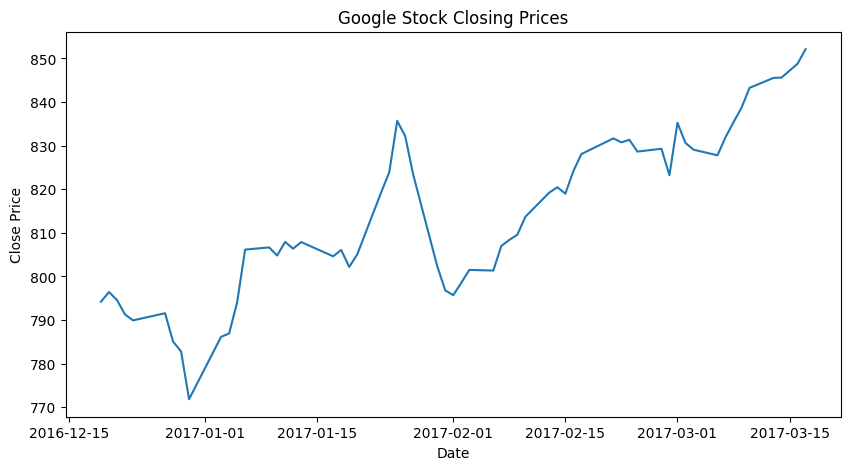

In [187]:
#Plot the closing Price , plt.plot(Linegraph)
plt.figure(figsize=(10,5))
plt.plot(df['Date'],df['Close'])
plt.title("Google Stock Closing Prices")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

In [188]:
#data=df['Close']->return a 1D array(Pandas Series,a column),df[['Close']]->return a Pandas dataframe(2d)
data=df[['Close']]
data

,Close
0,794.200012
1,796.419983
2,794.559998
3,791.260010
4,789.909973
...,...
56,845.539978
57,845.619995
58,847.200012
59,848.780029


In [189]:
#Prepare raw stock prices for neural network, lowest stck p->0,highest->1
scaler=MinMaxScaler(feature_range=(0,1))
scaled_data=scaler.fit_transform(data)

In [190]:
#Create empty list to store inp sequence and target output
X=[]
y=[]

In [191]:
#Use prev 10 days data (60 days needs more data points)
for i in range(10,len(scaled_data)):
    X.append(scaled_data[i-10:i,0])
    y.append(scaled_data[i, 0])
    

In [192]:
X=np.array(X)
y=np.array(y)

In [193]:
X=X.reshape(X.shape[0],X.shape[1],1)
len(X)

51

In [194]:
split=int(0.8*len(X))

X_train=X[:split]
X_test=X[split:]

y_train=y[:split]
y_test=y[split:]

In [195]:
model=Sequential()

model.add(SimpleRNN(50,activation='tanh',input_shape=(X_train.shape[1],1)))

model.add(Dense(1))
model.compile(optimizer='adam',loss='mean_squared_error')
model.fit(X_train,y_train,epochs=10,batch_size=8)

Epoch 1/10


c:\Users\mansi.apet\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0226
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0129 
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0122
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0122 
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0107
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0094 
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0101 
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0085 
Epoch 9/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0078 
Epoch 10/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0074


In [196]:
y_pred=model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step


In [197]:
#scaler back

y_pred=scaler.inverse_transform(y_pred) #tf returs a 2d array
#y_test is a 1d list but scaler needs a 2d array
y_test=scaler.inverse_transform(y_test.reshape(-1,1))


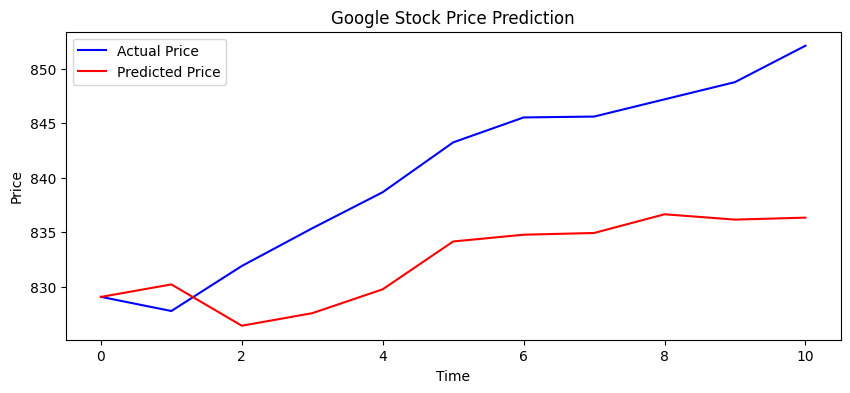

In [198]:
plt.figure(figsize=(10,4))

plt.plot(y_test,color='blue',label='Actual Price')
plt.plot(y_pred,color='red',label='Predicted Price')
plt.title("Google Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()

In [199]:
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print("RMSE:",rmse)
print("R2 Score:",r2)

RMSE: 9.571141302720424
R2 Score: -0.4328196890324576
